In [ ]:
"""
Session 5 (260129) Participation
Topic: Subplots and combining visualizations plus wrapping up remaining coding topics

Key ideas
- Use subplots to compare views side by side when it supports the message
- Use layout tools so labels and titles do not overlap
- Save figures with a stable file name for reproducibility
- Combine plot types in one figure when the relationship is meaningful
- Reminder from class: check paths and dependencies early when running scripts
"""

In [8]:
# install matplotlib-venn
!pip install matplotlib-venn


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45388 sha256=2e1d57ad21be23ddd67dcf09589c75d2c8d2eacdc89e5c60d1486d3f8fa23faf
  Stored in directory: /Users/moli/Library/Caches/pip/wheels/c2/47/0c/f014c55a1cfd56dce41a1cafd23e3c590652b5e71330cc181c
Successfully built matplotlib-venn


In [6]:
# install wordcloud
!pip install wordcloud


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud
from matplotlib_venn import venn2_unweighted


In [ ]:

df = sns.load_dataset("tips")
df.head()




,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [13]:
text = " ".join(df["sex"])


In [14]:
text = " ".join(df["day"])


In [15]:
df.shape, df.columns


((244, 7),
 Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object'))

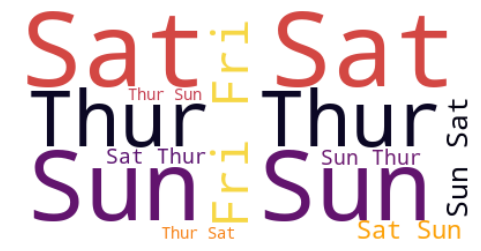

In [17]:
# Word cloud from tips dataset
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# choose a text column from tips
text = " ".join(df["day"].dropna().astype(str)) 

wordcloud = WordCloud(
    background_color="white",
    colormap="inferno"
).generate(text)

fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud, interpolation="bilinear")
ax.axis("off")
plt.show()



In [18]:
text = " ".join(
    df[["day", "time", "sex", "smoker"]].astype(str).fillna("").values.ravel()
)


/opt/anaconda3/lib/python3.12/site-packages/matplotlib_venn/_util.py:32: UserWarning: venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.
  warnings.warn(


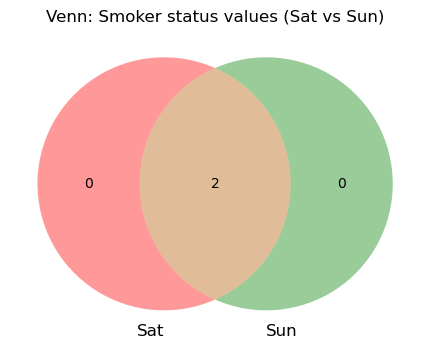

In [19]:
# Venn diagram using tips
from matplotlib_venn import venn2_unweighted

A = set(df.loc[df["day"] == "Sat", "smoker"].astype(str))  # smoker values seen on Sat
B = set(df.loc[df["day"] == "Sun", "smoker"].astype(str))  # smoker values seen on Sun

plt.figure(figsize=(6, 4))
venn2_unweighted([A, B], set_labels=("Sat", "Sun"))
plt.title("Venn: Smoker status values (Sat vs Sun)")
plt.show()


/opt/anaconda3/lib/python3.12/site-packages/matplotlib_venn/_util.py:32: UserWarning: venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.
  warnings.warn(


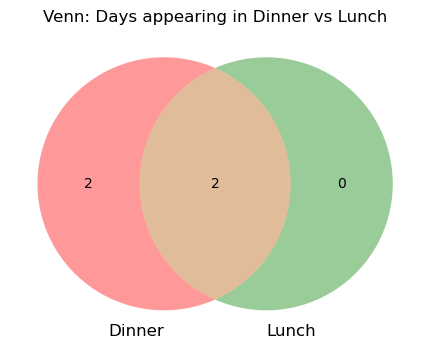

In [20]:
A = set(df.loc[df["time"] == "Dinner", "day"].astype(str))
B = set(df.loc[df["time"] == "Lunch", "day"].astype(str))

plt.figure(figsize=(6, 4))
venn2_unweighted([A, B], set_labels=("Dinner", "Lunch"))
plt.title("Venn: Days appearing in Dinner vs Lunch")
plt.show()


In [21]:
plt.savefig("session_05_output.png", dpi=300, bbox_inches="tight")


<Figure size 640x480 with 0 Axes>